<a href="https://colab.research.google.com/github/Betrand-nde/Projects/blob/main/logistic_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

In [43]:
data = pd.read_csv("smart_logistics_dataset.csv")

In [5]:
data.head()

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                1000 non-null   object 
 1   Asset_ID                 1000 non-null   object 
 2   Latitude                 1000 non-null   float64
 3   Longitude                1000 non-null   float64
 4   Inventory_Level          1000 non-null   int64  
 5   Shipment_Status          1000 non-null   object 
 6   Temperature              1000 non-null   float64
 7   Humidity                 1000 non-null   float64
 8   Traffic_Status           1000 non-null   object 
 9   Waiting_Time             1000 non-null   int64  
 10  User_Transaction_Amount  1000 non-null   int64  
 11  User_Purchase_Frequency  1000 non-null   int64  
 12  Logistics_Delay_Reason   737 non-null    object 
 13  Asset_Utilization        1000 non-null   float64
 14  Demand_Forecast          

In [7]:
data.isnull().sum()

,0
Timestamp,0
Asset_ID,0
Latitude,0
Longitude,0
Inventory_Level,0
Shipment_Status,0
Temperature,0
Humidity,0
Traffic_Status,0
Waiting_Time,0


In [8]:
data['Logistics_Delay_Reason'].unique()

array([nan, 'Weather', 'Traffic', 'Mechanical Failure'], dtype=object)

In [9]:
ds2 = data.fillna(0)

In [10]:
ds2.isnull().sum()

,0
Timestamp,0
Asset_ID,0
Latitude,0
Longitude,0
Inventory_Level,0
Shipment_Status,0
Temperature,0
Humidity,0
Traffic_Status,0
Waiting_Time,0


In [11]:
ds2.head()

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,0,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,0,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,0,71.6,270,1


In [12]:
ds3 = ds2.select_dtypes(include=[np.number]).dropna()

In [13]:
ds3.head()

,Latitude,Longitude,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,-65.7383,11.2497,390,27.0,67.8,38,320,4,60.1,285,1
1,22.2748,-131.7086,491,22.5,54.3,16,439,7,80.9,174,1
2,54.9232,79.5455,190,25.2,62.2,34,355,3,99.2,260,0
3,42.3900,-1.4788,330,25.4,52.3,37,227,5,97.4,160,1
4,-65.8477,47.9468,480,20.5,57.2,56,197,6,71.6,270,1


In [14]:
correlation_val = ds3.corr()['Logistics_Delay'].sort_values(ascending=False)
correlation_val

,Logistics_Delay
Logistics_Delay,1.000000
Latitude,0.039634
User_Transaction_Amount,0.013605
Longitude,0.011796
Humidity,-0.000504
Asset_Utilization,-0.003140
Inventory_Level,-0.003340
User_Purchase_Frequency,-0.017439
Demand_Forecast,-0.018621
Temperature,-0.038067


In [15]:
correlation_val = ds3.corr()['Asset_Utilization'].sort_values(ascending=False)
correlation_val

,Asset_Utilization
Asset_Utilization,1.000000
Temperature,0.046005
User_Transaction_Amount,0.038607
User_Purchase_Frequency,0.024445
Waiting_Time,0.018008
Inventory_Level,0.017041
Longitude,0.002916
Logistics_Delay,-0.003140
Latitude,-0.023606
Humidity,-0.030637


In [16]:
correlation_val = ds3.corr()['User_Transaction_Amount'].sort_values(ascending=False)
correlation_val

,User_Transaction_Amount
User_Transaction_Amount,1.000000
Asset_Utilization,0.038607
User_Purchase_Frequency,0.038406
Logistics_Delay,0.013605
Demand_Forecast,0.004531
Temperature,-0.006377
Waiting_Time,-0.017796
Longitude,-0.019753
Humidity,-0.034828
Latitude,-0.035171


In [17]:
correlation_val = ds3.corr()['Waiting_Time'].sort_values(ascending=False)
correlation_val

,Waiting_Time
Waiting_Time,1.000000
Longitude,0.031938
Humidity,0.029030
User_Purchase_Frequency,0.023582
Asset_Utilization,0.018008
Temperature,0.017392
User_Transaction_Amount,-0.017796
Inventory_Level,-0.020337
Latitude,-0.025667
Demand_Forecast,-0.030042


In [18]:
def detect_outliers_iqr(df, columns):
    outliers = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    return outliers

In [19]:
outliers = detect_outliers_iqr(ds3, ds3.columns)

In [20]:
ds3 = pd.concat([ds3,data['Asset_ID']],axis=1)
ds3

,Latitude,Longitude,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Logistics_Delay,Asset_ID
0,-65.7383,11.2497,390,27.0,67.8,38,320,4,60.1,285,1,Truck_7
1,22.2748,-131.7086,491,22.5,54.3,16,439,7,80.9,174,1,Truck_6
2,54.9232,79.5455,190,25.2,62.2,34,355,3,99.2,260,0,Truck_10
3,42.3900,-1.4788,330,25.4,52.3,37,227,5,97.4,160,1,Truck_9
4,-65.8477,47.9468,480,20.5,57.2,56,197,6,71.6,270,1,Truck_7
...,...,...,...,...,...,...,...,...,...,...,...,...
995,89.8701,73.6867,264,26.9,70.0,32,188,1,79.2,213,1,Truck_6
996,-10.4792,-177.1239,479,23.7,77.9,56,276,7,83.7,272,0,Truck_5
997,-71.0609,75.3714,347,21.0,63.1,35,382,5,74.8,275,0,Truck_2
998,-76.7910,18.3631,276,18.0,64.3,10,361,5,88.6,242,1,Truck_2


In [21]:
ls=ds3.groupby('Asset_ID')['Asset_ID'].agg('count').sort_values(ascending=False)
ls

,Asset_ID
Asset_ID,
Truck_8,109
Truck_4,107
Truck_2,105
Truck_10,105
Truck_6,103
Truck_7,102
Truck_9,94
Truck_5,93
Truck_3,93


In [22]:
ds3['Asset_ID'].unique()

array(['Truck_7', 'Truck_6', 'Truck_10', 'Truck_9', 'Truck_4', 'Truck_2',
       'Truck_8', 'Truck_3', 'Truck_5', 'Truck_1'], dtype=object)

In [23]:
data.head(2)

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1


In [24]:
data['Shipment_Status'].unique()

array(['Delayed', 'In Transit', 'Delivered'], dtype=object)

In [25]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Sample dataset
df = pd.DataFrame({'Color': ['Red', 'Green', 'Blue', 'Red', 'Blue', 'Green', 'Red']})

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoded = encoder.fit_transform(df[['Color']])

# Convert to DataFrame with category names
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Color']))

print(encoded_df)


   Color_Blue  Color_Green  Color_Red
0         0.0          0.0        1.0
1         0.0          1.0        0.0
2         1.0          0.0        0.0
3         0.0          0.0        1.0
4         1.0          0.0        0.0
5         0.0          1.0        0.0
6         0.0          0.0        1.0


In [26]:
import pandas as pd

# Example dataset
data = {'Color': ['Red', 'Green', 'Blue', 'Red', 'Blue', 'Green', 'Red']}
df = pd.DataFrame(data)

# Apply one-hot encoding
encoded_df = pd.get_dummies(df, columns=['Color'])

print(encoded_df)


   Color_Blue  Color_Green  Color_Red
0       False        False       True
1       False         True      False
2        True        False      False
3       False        False       True
4        True        False      False
5       False         True      False
6       False        False       True


In [27]:
ds4 = ds3.copy()
ds4.head()

,Latitude,Longitude,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Logistics_Delay,Asset_ID
0,-65.7383,11.2497,390,27.0,67.8,38,320,4,60.1,285,1,Truck_7
1,22.2748,-131.7086,491,22.5,54.3,16,439,7,80.9,174,1,Truck_6
2,54.9232,79.5455,190,25.2,62.2,34,355,3,99.2,260,0,Truck_10
3,42.3900,-1.4788,330,25.4,52.3,37,227,5,97.4,160,1,Truck_9
4,-65.8477,47.9468,480,20.5,57.2,56,197,6,71.6,270,1,Truck_7


In [28]:
from sklearn.preprocessing import OneHotEncoder

In [29]:
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoded_data = encoder.fit_transform(ds4[['Asset_ID']])

In [30]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_data = encoder.fit_transform(ds4[['Asset_ID']])

ed_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Asset_ID']))

In [31]:
ed_df

,Asset_ID_Truck_1,Asset_ID_Truck_10,Asset_ID_Truck_2,Asset_ID_Truck_3,Asset_ID_Truck_4,Asset_ID_Truck_5,Asset_ID_Truck_6,Asset_ID_Truck_7,Asset_ID_Truck_8,Asset_ID_Truck_9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
996,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
997,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
998,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
ds5 = pd.concat([ds4,ed_df],axis=1)

In [33]:
ds5.head()

,Latitude,Longitude,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,...,Asset_ID_Truck_1,Asset_ID_Truck_10,Asset_ID_Truck_2,Asset_ID_Truck_3,Asset_ID_Truck_4,Asset_ID_Truck_5,Asset_ID_Truck_6,Asset_ID_Truck_7,Asset_ID_Truck_8,Asset_ID_Truck_9
0,-65.7383,11.2497,390,27.0,67.8,38,320,4,60.1,285,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,22.2748,-131.7086,491,22.5,54.3,16,439,7,80.9,174,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,54.9232,79.5455,190,25.2,62.2,34,355,3,99.2,260,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,42.3900,-1.4788,330,25.4,52.3,37,227,5,97.4,160,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-65.8477,47.9468,480,20.5,57.2,56,197,6,71.6,270,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [34]:
ds5.drop(['Asset_ID','Longitude','Latitude'],axis=1,inplace=True)

In [35]:
from matplotlib import pyplot as plt
import seaborn as sns

<Axes: >

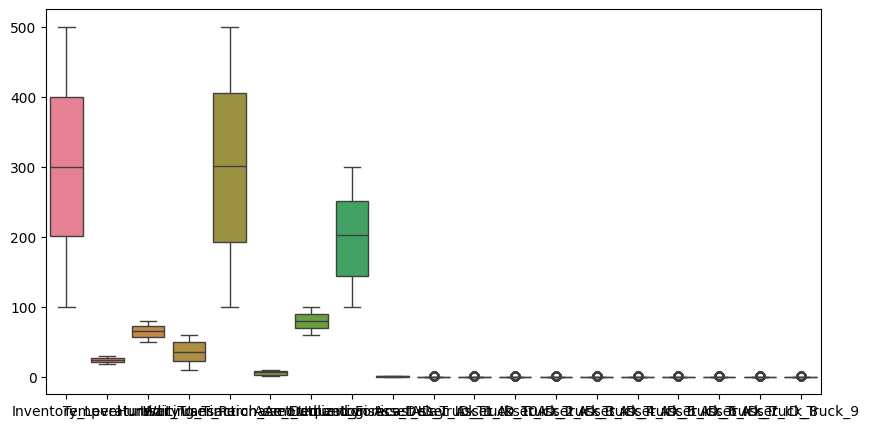

In [36]:
plt.figure(figsize=(10,5))
sns.boxplot(data=ds5)


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_train = ds5.drop(['Logistics_Delay'],axis=1)
y_train = ds5['Logistics_Delay']

X_train,X_test,y_train,y_test = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

models = {
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"{name} Accuracy: {accuracy}")

Random Forest Accuracy: 0.565
Logistic Regression Accuracy: 0.505
SVM Accuracy: 0.545
Decision Tree Accuracy: 0.56
KNN Accuracy: 0.52


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split # Importing train_test_split
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder for encoding 'Asset_ID'

X_train = ds5.drop(['Logistics_Delay'],axis=1) # Drop 'Asset_ID' from X_train
y_train = ds5['Logistics_Delay']



X_train,X_test,y_train,y_test = train_test_split(X_train,y_train,test_size=0.4,random_state=50)

models = {
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}


for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"{name} Accuracy: {accuracy}")

Random Forest Accuracy: 0.5175
Logistic Regression Accuracy: 0.54
SVM Accuracy: 0.5475
Decision Tree Accuracy: 0.535
KNN Accuracy: 0.5425


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
from sklearn.ensemble import RandomForestRegressor # Changed to Regressor
from sklearn.linear_model import LinearRegression # Changed to Regression
from sklearn.svm import SVR # Changed to Regression
from sklearn.tree import DecisionTreeRegressor # Changed to Regressor
from sklearn.neighbors import KNeighborsRegressor # Changed to Regressor
from sklearn.metrics import mean_squared_error, r2_score # Added regression metrics
from sklearn.model_selection import train_test_split

X_train = ds5.drop(['Asset_Utilization'],axis=1)
y_train = ds5['Asset_Utilization']

X_train,X_test,y_train,y_test = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

models = {
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "SVM": SVR(),
    "Decision Tree": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"{name} MSE: {mse}, R2: {r2}")

Random Forest MSE: 135.60505401499998, R2: -0.08931395914997142
Linear Regression MSE: 131.78599783302286, R2: -0.058635521388016754
SVM MSE: 127.28839709718203, R2: -0.02250634242915095
Decision Tree MSE: 280.14475, R2: -1.2503998023836411
KNN MSE: 164.07769800000003, R2: -0.3180344059803468


In [45]:
String_data = data.astype(str)

In [46]:
String_data.describe()

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,10,1000,1000,366,3,121,291,3,51,365,10,4,366,200,2
top,2024-09-18 19:39:24,Truck_8,59.8356,-114.4198,403,Delayed,22.8,74.2,Detour,51,421,9,Weather,66.8,111,1
freq,1,109,1,1,8,350,18,12,345,32,9,110,267,8,12,566


In [47]:
String_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Timestamp                1000 non-null   object
 1   Asset_ID                 1000 non-null   object
 2   Latitude                 1000 non-null   object
 3   Longitude                1000 non-null   object
 4   Inventory_Level          1000 non-null   object
 5   Shipment_Status          1000 non-null   object
 6   Temperature              1000 non-null   object
 7   Humidity                 1000 non-null   object
 8   Traffic_Status           1000 non-null   object
 9   Waiting_Time             1000 non-null   object
 10  User_Transaction_Amount  1000 non-null   object
 11  User_Purchase_Frequency  1000 non-null   object
 12  Logistics_Delay_Reason   1000 non-null   object
 13  Asset_Utilization        1000 non-null   object
 14  Demand_Forecast          1000 non-null   

In [48]:
String_data = String_data.drop(['Timestamp'],axis=1)

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer, BertForMaskedLM, RobertaTokenizer, RobertaForMaskedLM
import torch
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
!pip install catboost
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.8 MB/s eta 0:00:00


In [50]:
!pip install catboost  # Make sure CatBoost is installed.
from catboost import CatBoostClassifier  # Import the classifier class.

In [51]:
def load_and_preprocess_data(data):
    # Convert all features to string type
    for column in data.columns:
        if column != 'Timestamp':  # Keep timestamp as datetime
            data[column] = data[column].astype(str)

    return data

In [52]:
data_string = load_and_preprocess_data(data)
data_string.dtypes

,0
Timestamp,object
Asset_ID,object
Latitude,object
Longitude,object
Inventory_Level,object
Shipment_Status,object
Temperature,object
Humidity,object
Traffic_Status,object
Waiting_Time,object


In [53]:
class MLMPredictor:
    def __init__(self, model_name='bert-base-uncased'):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        if 'roberta' in model_name:
            self.tokenizer = RobertaTokenizer.from_pretrained(model_name)
            self.model = RobertaForMaskedLM.from_pretrained(model_name).to(self.device)
        else:
            self.tokenizer = BertTokenizer.from_pretrained(model_name)
            self.model = BertForMaskedLM.from_pretrained(model_name).to(self.device)

    def predict_missing_value(self, text, mask_position):
        inputs = self.tokenizer(text, return_tensors='pt')
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model(**inputs)
            predictions = outputs.logits
            predicted_token_id = predictions[0, mask_position].argmax(dim=0)
            predicted_token = self.tokenizer.decode([predicted_token_id])

        return predicted_token

In [54]:
bert_predictor = MLMPredictor('bert-base-uncased')
roberta_predictor = MLMPredictor('roberta-base')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [55]:
def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100),
        'XGBoost': XGBClassifier(),
        'LightGBM': LGBMClassifier(),
        'CatBoost': CatBoostClassifier(verbose=False),
        'SVM': SVC()
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results[name] = accuracy

    return results


In [56]:
for column in data.columns:
        if data[column].isnull().any():
            for idx in data[data[column].isnull()].index:
                context = f"The {column} is [MASK]."
            bert_pred = bert_predictor.predict_missing_value(context, mask_position=3)
            roberta_pred = roberta_predictor.predict_missing_value(context, mask_position=3)
            final_pred = bert_pred  # or implement more sophisticated selection
            data.loc[idx, column] = final_pred


In [57]:
le = LabelEncoder()
for column in data.columns:
    if column != 'Timestamp':
        data[column] = le.fit_transform(data[column])


In [63]:
data.drop(['Timestamp'],axis=1,inplace=True)
data.dtypes

,0
Asset_ID,int64
Latitude,int64
Longitude,int64
Inventory_Level,int64
Shipment_Status,int64
Temperature,int64
Humidity,int64
Traffic_Status,int64
Waiting_Time,int64
User_Transaction_Amount,int64


In [64]:
x = data.drop(['Logistics_Delay'],axis=1)
y = data['Logistics_Delay']

In [65]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [66]:
results = train_and_evaluate_models(X_train, X_test, y_train, y_test)
results

[LightGBM] [Info] Number of positive: 457, number of negative: 343
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000452 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1815
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.571250 -> initscore=0.286953
[LightGBM] [Info] Start training from score 0.286953
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

{'Random Forest': 1.0,
 'XGBoost': 1.0,
 'LightGBM': 1.0,
 'CatBoost': 1.0,
 'SVM': 0.545}

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_train = data.drop(['Logistics_Delay'],axis=1)
y_train = data['Logistics_Delay']

X_train,X_test,y_train,y_test = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

models = {
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"{name} Accuracy: {accuracy}")

Random Forest Accuracy: 1.0
Logistic Regression Accuracy: 0.915
SVM Accuracy: 0.545
Decision Tree Accuracy: 1.0
KNN Accuracy: 0.51


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


fine Tunening